**Praktikum 2 (K-Means)**

Belajar cara melakukan clustering menggunakan algoritma KMeans
pada dataset penghasilan publik. Memahami cara memilih fitur yang relevan, menentukan jumlah
cluster yang optimal, dan menganalisis hasil clustering.

**1. Import semua library yang diperlukan.**

Library utama adalah Sklearn dengan alat bantu Pandas untuk pengelolaan ekspor dan impor file serta
matplotlib untuk pembuatan grafik.

In [ ]:
!pip install kagglehub[pandas-datasets]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set_style("whitegrid")
print("Library berhasil diimpor!")

Library berhasil diimpor!


**2. Pemuatan dan Eksplorasi Data:**

Tautkan dataset dari publik yaitu kaggle ‘Mall Customer Segmentation Data’.

In [ ]:
# Set the path to the file you'd like to load
file_path = "Mall_Customers.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "vjchoudhary7/customer-segmentation-tutorial-in-python",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_631/4226602478.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
First 5 records:    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Menampilkan Jumlah data untuk melihat info dataset

In [ ]:
print(f"Jumlah Data dalam DataFrame: {df.shape[0]}")

Jumlah Data dalam DataFrame: 200


**3. Pemilihan Fitur:**

Pilih fitur 'Annual Income (k$)' dan 'Spending Score (1-100)' sebagai variabel untuk
clustering.

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

**4. Penerapan K-Means:**

Latih model algoritma K-Means untuk membagi data menjadi 3 kelompok (K=3).

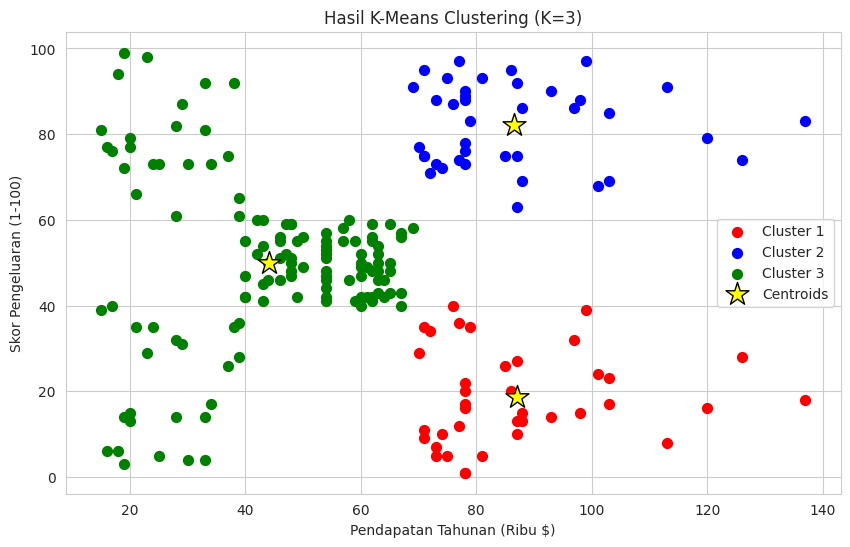

In [ ]:
# Menerapkan algoritma K-Means dengan K = 3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, c='green', label='Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('Hasil K-Means Clustering (K=3)')
plt.xlabel('Pendapatan Tahunan (Ribu $)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend()
plt.show()

**5. Penentuan K Optimal (Metode Elbow):**

a. Lakukan perulangan untuk melatih model dengan nilai K dari 1 hingga 10, lalu simpan nilai tingkat
kesalahan/jarak (WCSS atau Inersia) dari masing-masing percobaan.

b. Tampilkan grafik garis berdasarkan nilai WCSS yang diperoleh untuk mencari titik "siku".

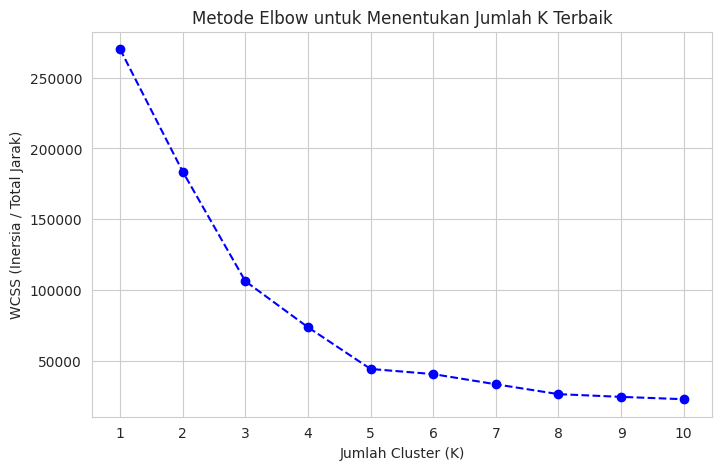

In [ ]:
wcss = []

# Mencoba nilai K dari 1 hingga 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# Membuat grafik Garis (Line Plot) untuk Metode Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow untuk Menentukan Jumlah K Terbaik')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inersia / Total Jarak)')
plt.xticks(range(1, 11))
plt.show()

**6. Penerapan K Optimal (K=5)**

a. Latih ulang model algoritma K-Means untuk membagi data ke dalam 5 kelompok (K=5), sesuai
dengan jumlah paling ideal yang didapat dari Metode Elbow sebelumnya.

b. Tampilkan hasil akhir pengelompokan ke dalam grafik, di mana kelima cluster dibedakan dengan
warna yang spesifik (merah, biru, hijau, cyan, dan magenta)

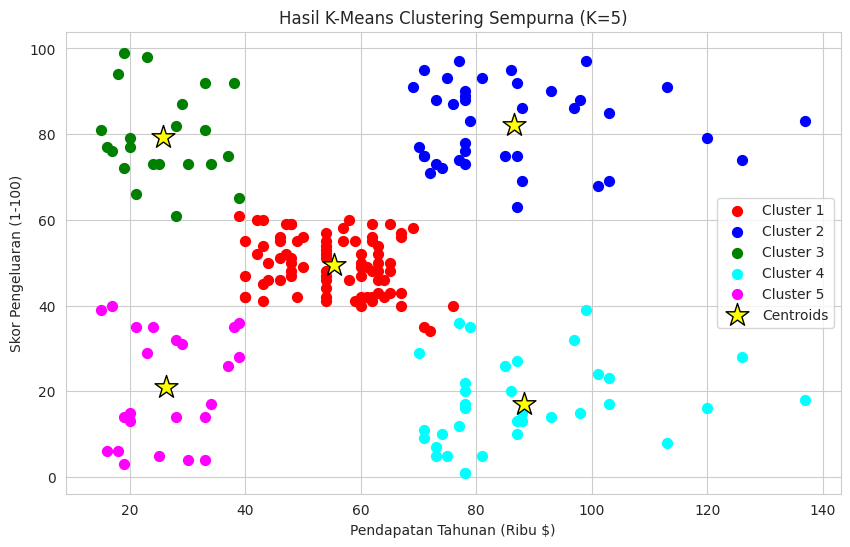

In [ ]:
# Melatih ulang model dengan K yang benar (K=5)
kmeans_ideal = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init='auto')
y_kmeans_ideal = kmeans_ideal.fit_predict(X)

plt.figure(figsize=(10, 6))

plt.scatter(X[y_kmeans_ideal == 0, 0], X[y_kmeans_ideal == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans_ideal == 1, 0], X[y_kmeans_ideal == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans_ideal == 2, 0], X[y_kmeans_ideal == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans_ideal == 3, 0], X[y_kmeans_ideal == 3, 1], s=50, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans_ideal == 4, 0], X[y_kmeans_ideal == 4, 1], s=50, c='magenta', label='Cluster 5')

plt.scatter(kmeans_ideal.cluster_centers_[:, 0], kmeans_ideal.cluster_centers_[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('Hasil K-Means Clustering Sempurna (K=5)')
plt.xlabel('Pendapatan Tahunan (Ribu $)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend()
plt.show()

Langkah tambahan/opsional sebelum menjalankan K-Means, bisa menentukan manual posisi centroid.

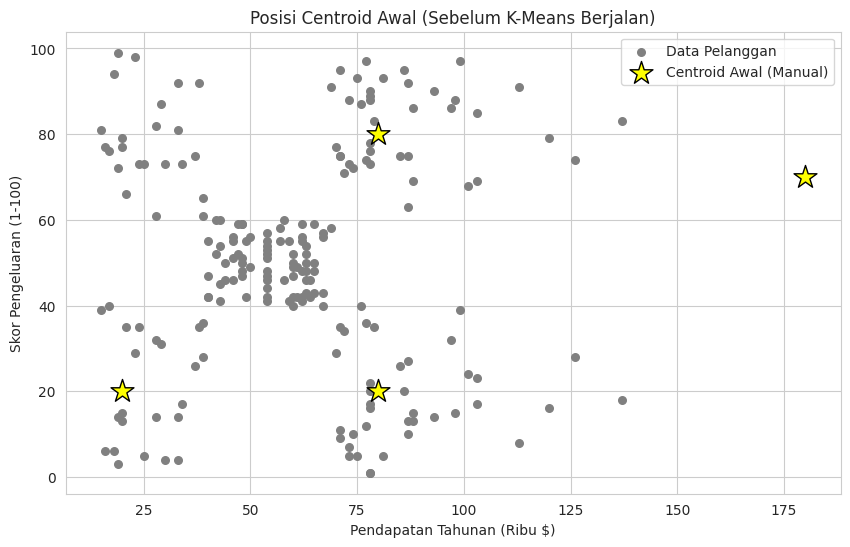

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

centroid_manual = np.array([
    [20, 20],
    [80, 80],
    [180, 70],
    [80, 20]
])

plt.figure(figsize=(10, 6))

plt.scatter(X[:, 0], X[:, 1], c='grey', s=30, label='Data Pelanggan')

plt.scatter(centroid_manual[:, 0], centroid_manual[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', label='Centroid Awal (Manual)')

plt.title('Posisi Centroid Awal (Sebelum K-Means Berjalan)')
plt.xlabel('Pendapatan Tahunan (Ribu $)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend()
plt.show()